**Lasso Regression**
**Goal:**
 1. Understand L1 Regularization
 2. Compare with Ridge Regression
 3. Observe feature selection

Lasso can shrink some coefficients to exactly zero.

In [ ]:
# importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

In [2]:
# Synthetic dataset 
np.random.seed(42)

X = np.linspace(0, 10, 100)

y = (
    0.5 * X**3
    - 4 * X**2
    + 10 * X
    + np.random.randn(100) * 20
)

X = X.reshape(-1, 1)

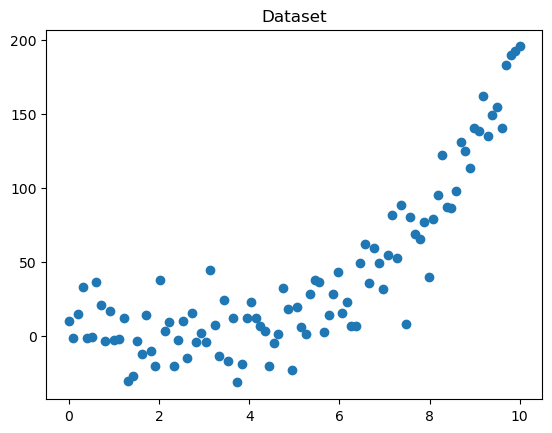

In [3]:
plt.scatter(X, y)

plt.title("Dataset")

plt.show()

In [4]:
poly = PolynomialFeatures(degree=10)

X_poly = poly.fit_transform(X)

In [5]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_poly,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
# Ridge Model
ridge = Ridge(alpha=10)

ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.49068e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


In [7]:
# Lasso Model
lasso = Lasso(alpha=1)

lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.327e+04, tolerance: 2.756e+01
  model = cd_fast.enet_coordinate_descent(


In [8]:
print("Ridge R2 :", r2_score(y_test, y_pred_ridge))
print("Lasso R2 :", r2_score(y_test, y_pred_lasso))

Ridge R2 : 0.8586696993243917
Lasso R2 : 0.8686246489180309


In [9]:
print(
    "Number of coefficients made zero:",
    np.sum(lasso.coef_ == 0)
)

Number of coefficients made zero: 1


## Feature Selection

Lasso can force some coefficients to become exactly zero.

This removes less important features automatically.

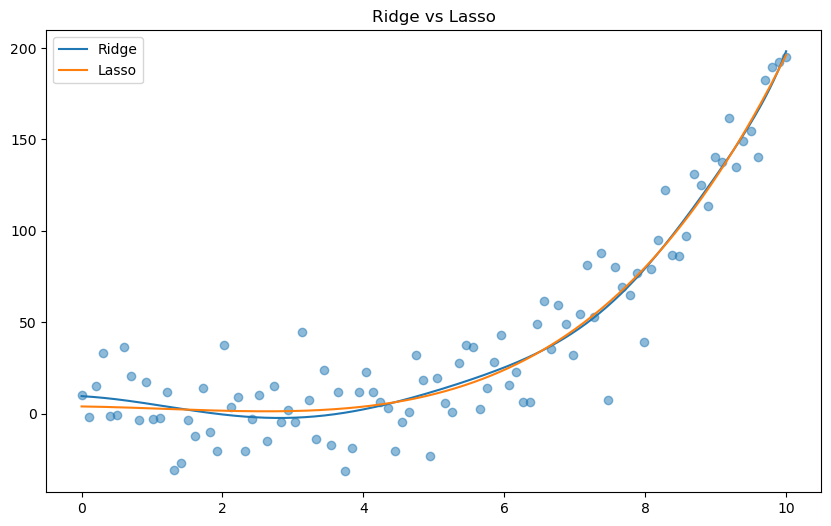

In [10]:
X_plot = np.linspace(0, 10, 500).reshape(-1, 1)

X_plot_poly = poly.transform(X_plot)

y_plot_ridge = ridge.predict(X_plot_poly)
y_plot_lasso = lasso.predict(X_plot_poly)

plt.figure(figsize=(10,6))

plt.scatter(X, y, alpha=0.5)

plt.plot(
    X_plot,
    y_plot_ridge,
    label="Ridge"
)

plt.plot(
    X_plot,
    y_plot_lasso,
    label="Lasso"
)

plt.legend()

plt.title("Ridge vs Lasso")

plt.show()

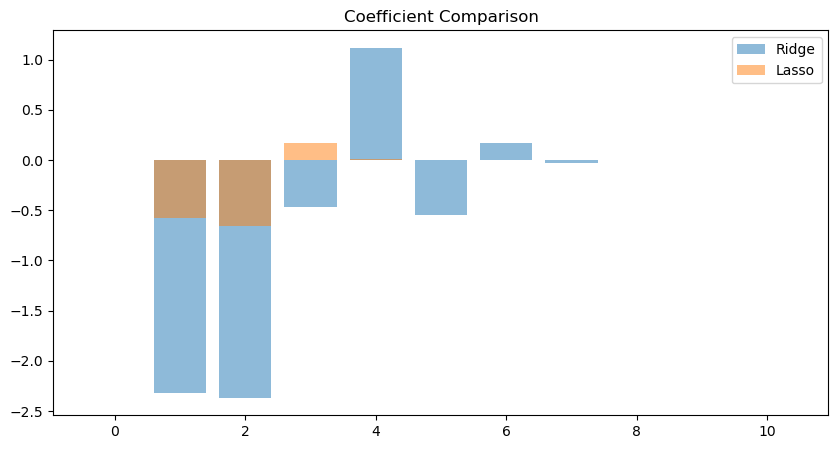

In [11]:
plt.figure(figsize=(10,5))

plt.bar(
    range(len(ridge.coef_)),
    ridge.coef_,
    alpha=0.5,
    label="Ridge"
)

plt.bar(
    range(len(lasso.coef_)),
    lasso.coef_,
    alpha=0.5,
    label="Lasso"
)

plt.legend()

plt.title("Coefficient Comparison")

plt.show()

# Lasso Regression

Lasso uses L1 Regularization.

Loss = MSE + λΣ|w|

Key Idea:

- Penalizes large coefficients
- Can make coefficients exactly zero

Advantages:

- Reduces overfitting
- Performs feature selection
- Produces simpler models

Difference from Ridge:

Ridge:
- Shrinks coefficients
- Keeps all features

Lasso:
- Shrinks coefficients
- Can remove features completely